In [ ]:
import sys; from pathlib import Path
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.insert(0, str(src_dir))
from imports import *
one_drive_dir = mi.Utilities.get_one_drive_dir()


In [ ]:
#path_main_folder = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Raw_Data_ACF_HT/ACF_data')
path_main_folder = Path('/Volumes/LaCie/UTag_paper_data/ACF')
results_folder = path_main_folder.joinpath( 'results_Spots_Properties')
if not results_folder.exists():
    results_folder.mkdir()

In [3]:
def read_lif_file_print_intensity(folder_with_lif_files):
    # read all the files in the folder
    files = [f for f in folder_with_lif_files.iterdir() if f.is_file() and f.suffix == '.lif']
    print(f'Found {len(files)} files in {folder_with_lif_files.name}')
    print('\n')
    
    # iterate over the lif files
    for lif_file in files:
        list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth, _,list_intensities,_ = mi.ReadLif(lif_file,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
        # print the lif_file name and the list_intensities.
        print(f'Processing {lif_file.name}')
        for i, intensity in enumerate(list_intensities):
            # print the image name using list_names[i] and the intensity
            image_name = list_names[i] if i < len(list_names) else f'Image {i}'
            print(f'{image_name} has intensity {intensity[1]}, and a pixel_xy_um of {np.round(pixel_xy_um,3)}')
            print('-----------------------')
        print('\n')
    return pixel_xy_um



In [4]:
# this is the pixel size used in the microscope.
pixel_xy_um = 0.12989318982387477

In [5]:
def dataset_selection(dataset,control_spots_mode=False):
    if control_spots_mode == True:
        dataframe_prefix='random_location_spots_'
    else:
        dataframe_prefix='tracking_'
    if dataset == 'utag':
        folder_with_files = path_main_folder.joinpath('UTag_ACF')
        plot_name = 'utag'
    elif dataset == 'utag_c_free':
        folder_with_files = path_main_folder.joinpath('UTag_CF_ACF')
        plot_name = 'utag_c_free'
    if dataset == 'suntag':
        folder_with_files = path_main_folder.joinpath('SunTag_ACF')
        plot_name = 'suntag'
    elif dataset == 'alfatag':
        folder_with_files = path_main_folder.joinpath('AlfaTag_ACF')
        plot_name = 'alfatag'
    if control_spots_mode == True:
        plot_name = plot_name + '_control_spots'
    return folder_with_files, plot_name, dataframe_prefix

In [ ]:
def load_tracking_data(root_folder: Path, selected_field: str, dataframe_prefix='tracking_', frame: int = None):
    """
    Load and process all tracking CSV files found in subfolders whose names include 'results_'.
    
    This function extracts the values for the specified 'selected_field' from each CSV file whose name 
    contains the given dataframe_prefix, and concatenates the results into a numpy array. Optionally,
    it extracts data corresponding to a specific frame value.
    
    If 'frame' is provided:
      - If the CSV file contains a column named "frame", only the rows with that frame value are used.
      - Otherwise, the function treats 'frame' as a row index and extracts that single value from the 
        selected field (if available).
    If 'frame' is None, the entire column is extracted.
    
    Parameters
    ----------
    root_folder : Path
        The root folder containing subfolders with CSV tracking data.
    selected_field : str
        The name of the column to extract from each CSV file.
    dataframe_prefix : str, optional
        Prefix used to identify the tracking data CSV files (default is 'tracking_').
    frame : int, optional
        Specific frame value (or row index) to extract from the selected column. Default is None (extract all data).
    
    Returns
    -------
    values_arrays : np.ndarray
        A numpy object array where each element is a numpy array of extracted values from a CSV file.
    number_of_cells : int
        Total number of RNA spots, calculated as the sum of rows across all CSV files.
    """
    # Get subfolders that include 'results_' in their name.
    subfolders = [folder for folder in root_folder.iterdir() if folder.is_dir() and 'results_' in folder.name]

    # print subfolders
    #print(f'Found subfolders: {[folder.name for folder in subfolders]}')
    # Get tracking CSV files from these subfolders (files with dataframe_prefix in their name).
    tracking_files = [file 
                      for folder in subfolders 
                      for file in folder.iterdir() 
                      if dataframe_prefix in file.name and file.suffix.lower() == '.csv' and not file.name.startswith('._')]
    number_of_cells = 0
    list_extracted_values = []
    for tracking_file in tracking_files:
        #print(f'Processing {tracking_file.name}')
        df = pd.read_csv(tracking_file)
        # Decide how to extract the data based on frame parameter.
        if frame is not None:
            if "frame" in df.columns:
                # Filter rows where the 'frame' column matches the specified frame.
                values = df[df["frame"] == frame][selected_field].values
            else:
                # Otherwise, treat 'frame' as a row index (if available)
                if frame < len(df):
                    values = np.array([df[selected_field].iloc[frame]])
                else:
                    values = np.array([])  # frame index out of range; return empty array for this file.
        else:
            values = df[selected_field].values
        # Remove NaN values from the extracted values.
        values = values[~np.isnan(values)]
        list_extracted_values.append(values)
        # Count every row as one RNA spot regardless of frame selection.
        number_of_cells += len(df)
    # Convert the list of arrays into a numpy object array.
    values_arrays = np.array(list_extracted_values, dtype=object)
    return values_arrays, number_of_cells

In [7]:
def extract_data (selected_field,list_datasets,selected_frame=None):
    list_extracted_data= []
    list_total_number_of_cells = []
    for dataset in list_datasets:
        df = pd.DataFrame()
        #print(f'Processing dataset: {dataset}' '\n') 
        folder_with_files, plot_name, dataframe_prefix = dataset_selection(dataset,control_spots_mode=False)
        array_data_all_cells, total_number_of_cells = load_tracking_data(folder_with_files, selected_field=selected_field,frame=selected_frame)
        list_extracted_data.append(array_data_all_cells)
        list_total_number_of_cells.append(total_number_of_cells)

    # for each numpy array inside a given element in the list merge them into a single numpy array
    list_merged_data = [np.concatenate(array_data) for array_data in list_extracted_data]
    return list_extracted_data, list_merged_data


In [8]:
def plot_repetition_means_box_swarm_plot(
    conditions_data, # list of np.ndarray: each element is a numpy array of repetition data for a condition
    condition_labels,  # list of str: label for each condition (x-axis category)
    x_label="Condition",
    y_label="Mean Value",
    title="",
    figsize=(6, 4),
    tick_size=16,
    swarm_color="black",
    y_lim=None,
    show_stats=False,
    save_dir=None,  # Path or str; if provided, the plot will be saved in this directory
    plot_name = 'temp',
    max_percentile_significance=99.5,
    calculate_stats=True,  # NEW: Always calculate stats by default
    x_tick_rotation=0,  # NEW: Rotation angle for x-axis labels
):
    """
    Calculate the mean of each repetition within each condition and create a boxplot 
    with whiskers overlaid by a swarm plot. Optionally, perform pairwise statistical 
    comparisons between conditions and add significance bars.
    
    Parameters
    ----------
    conditions_data : list
        A list where each element corresponds to a condition. Each condition is an iterable of 
        NumPy arrays representing repetition data.
    condition_labels : list of str
        Labels for each condition that will appear on the x-axis.
    x_label : str, optional
        Label for the x-axis (default "Condition").
    y_label : str, optional
        Label for the y-axis (default "Mean Value").
    title : str, optional
        Plot title (default is an empty string).
    figsize : tuple, optional
        Figure size in inches (default (6, 4)).
    tick_size : int, optional
        Font size for tick labels (default 16).
    swarm_color : str, optional
        Color for the swarmplot points (default "black").
    y_lim : tuple, optional
        y-axis limits as a tuple (min, max); if provided, applied via ax.set_ylim().
    show_stats : bool, optional
        If True, pairwise significance bars (using the Mann–Whitney U test) are added to plot.
    calculate_stats : bool, optional
        If True, statistical comparisons are calculated and printed (default True).
    save_dir : Path or str, optional
        Directory in which to save the plot (as PNG and SVG). If None, the plot is not saved.
    x_tick_rotation : float, optional
        Rotation angle for x-axis tick labels in degrees (default 0). 
        Common values: 0 (horizontal), 45 (diagonal), 90 (vertical).
    
    Returns
    -------
    ax : matplotlib Axes object
        The Axes object containing the plot.
    p_values : dict
        Dictionary containing p-values for all pairwise comparisons.
    """

    # Set Seaborn style.
    sns.set_style("ticks")
    
    # Calculate repetition means for each condition.
    mean_values = []
    condition_list = []
    for cond_idx, repetitions in enumerate(conditions_data):
        for rep in repetitions:
            rep_mean = np.nanmean(rep)
            mean_values.append(rep_mean)
            condition_list.append(condition_labels[cond_idx])
    
    # Create a DataFrame with the calculated means.
    df = pd.DataFrame({
        "Mean": mean_values,
        "Condition": condition_list
    })
    
    # Create the figure with a white background.
    plt.figure(figsize=figsize, facecolor='white')
    ax = sns.boxplot(
        x="Condition",
        y="Mean",
        data=df,
        order=condition_labels,
        showfliers=False,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'red'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        linewidth=1.5,
        whis=[5, 95],
        width=0.5,
    )
    ax.set_facecolor('white')
    
    # Overlay the swarmplot.
    sns.swarmplot(
        x="Condition",
        y="Mean",
        data=df,
        order=condition_labels,
        color=swarm_color,
        size=5,
    )
    
    # Set labels and title using Arial font with the specified tick size.
    ax.set_xlabel(x_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.set_ylabel(y_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.set_title(title, fontsize=tick_size + 4, fontname="Arial", color='black')
    
    ax.tick_params(axis='x', labelsize=tick_size , colors='black')
    ax.tick_params(axis='y', labelsize=tick_size, colors='black')
    
    # Apply rotation to x-axis labels and set font
    for label in ax.get_xticklabels():
        label.set_rotation(x_tick_rotation)
        label.set_fontname("Arial")
        label.set_ha('right' if x_tick_rotation > 0 else 'center')
    for label in ax.get_yticklabels():
        label.set_fontname("Arial")
    
    # Initialize variables for stats (moved outside conditional blocks)
    global_max = np.nanpercentile(df["Mean"].to_numpy(), max_percentile_significance)
    global_min = np.nanmin(df["Mean"].to_numpy())
    global_range = global_max - global_min if (global_max - global_min) != 0 else 1
    offset = 0.15 * global_range
    bar_height = 0.02 * global_range
    k = 0
    p_values = {}
    

    print(f"\n--- Mean Values for {plot_name} ---")
    for cond in condition_labels:
        group_data = df[df["Condition"] == cond]["Mean"]
        group_mean = np.nanmean(group_data)
        group_std = np.nanstd(group_data)
        n_samples = len(group_data)
        group_sem = group_std / np.sqrt(n_samples) if n_samples > 1 else 0
        print(f"  {cond}: {group_mean:.3f} ± {group_sem:.4f} (n={n_samples})")
    print("--- End Mean Values ---\n")

    # Calculate statistical comparisons (always done if calculate_stats=True)
    if calculate_stats and len(condition_labels) > 1:
        print(f"\n--- Statistical Comparisons for {plot_name} ---")
        num_conditions = len(condition_labels)        
        for i in range(num_conditions - 1):
            for j in range(i + 1, num_conditions):
                group1 = df[df["Condition"] == condition_labels[i]]["Mean"]
                group2 = df[df["Condition"] == condition_labels[j]]["Mean"]
                # remove NaN values
                group1 = group1[~np.isnan(group1)]
                group2 = group2[~np.isnan(group2)]
                if len(group1) > 0 and len(group2) > 0:
                    stat, p = mannwhitneyu(group1, group2)
                    # Store p-value in dictionary
                    comparison_key = f"{condition_labels[i]} vs {condition_labels[j]}"
                    p_values[comparison_key] = p
                else:
                    p = np.nan
                    comparison_key = f"{condition_labels[i]} vs {condition_labels[j]}"
                    p_values[comparison_key] = p
                # Determine significance marker.
                if p < 0.0001:
                    sig = '****'
                elif p < 0.001:
                    sig = '***'
                elif p < 0.01:
                    sig = '**'
                elif p < 0.05:
                    sig = '*'
                else:
                    sig = 'ns'
                print(f"  {condition_labels[i]} vs {condition_labels[j]}: p = {p:.6f} ({sig})")
                # Only draw significance bars if show_stats is True
                if show_stats:
                    if sig != 'ns':
                        x1 = i
                        x2 = j
                        y_line = global_max + offset * (k + 1)
                        # Draw the significance bar.
                        ax.plot([x1, x1, x2, x2],
                                [y_line, y_line + bar_height, y_line + bar_height, y_line],
                                lw=1.5, c='k')
                        # Add the significance text.
                        ax.text((x1 + x2) * 0.5, y_line + bar_height,
                                sig, ha='center', va='bottom',
                                color='k', fontsize=tick_size-4, fontname="Arial")
                        k += 1  # Increase counter for positioning
        print("--- End Statistical Comparisons ---\n")
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)  # Make border lines thicker
        spine.set_color('black')   # Ensure they're black
    
    # Make tick marks thicker and longer
    ax.tick_params(axis='both', which='major', 
                   width=2.0,      # Thickness of tick marks
                   length=6,       # Length of tick marks
                   colors='black') # Color of tick marks

    # Set y-limits: use provided limits if show_stats=False, otherwise adjust for bars
    if y_lim is not None and not show_stats:
        ax.set_ylim(y_lim)
    elif show_stats and k > 0:
        highest_bar = global_max + offset * k + bar_height
        padding = 0.1 * (highest_bar - global_min)
        ax.set_ylim(global_min, highest_bar + padding)
    elif y_lim is not None:
        ax.set_ylim(y_lim)
    
    # Save the plot as PNG and SVG if save_dir is provided.
    if save_dir is not None:
        plt.savefig(save_dir.joinpath(plot_name+".png"), dpi=600, bbox_inches='tight')
        plt.savefig(save_dir.joinpath(plot_name+".svg"), dpi=600, bbox_inches='tight')
    
    plt.show()
    return ax, p_values


--- Mean Values for spot_intensity ---
  UTag: 2227.161 ± 229.3464 (n=19)
  UTag($\Delta$Cys): 2090.201 ± 264.7249 (n=14)
  SunTag: 2170.292 ± 228.0485 (n=16)
  ALFA-tag: 2360.443 ± 238.7776 (n=11)
--- End Mean Values ---


--- Statistical Comparisons for spot_intensity ---
  UTag vs UTag($\Delta$Cys): p = 0.812836 (ns)
  UTag vs SunTag: p = 0.907735 (ns)
  UTag vs ALFA-tag: p = 0.763220 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.819150 (ns)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.366372 (ns)
  SunTag vs ALFA-tag: p = 0.474286 (ns)
--- End Statistical Comparisons ---



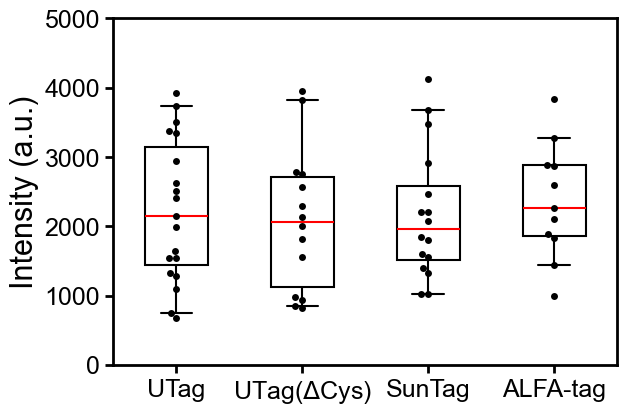

In [9]:
selected_frame =  None

list_datasets = [ 'utag', 'utag_c_free','suntag', 'alfatag']
list_constructs_names = ['UTag', r'UTag($\Delta$Cys)','SunTag', 'ALFA-tag']

figsize=(6.5, 4.5)
tick_size = 18
show_stats = True

selected_field = 'spot_int_ch_0'  
list_extracted_data, list_merged_data = extract_data(selected_field, list_datasets, selected_frame=selected_frame)
_,_, = plot_repetition_means_box_swarm_plot(
    list_extracted_data,
    list_constructs_names,
    x_label="",
    y_label="Intensity (a.u.)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(0, 5000),
    show_stats=show_stats,
    max_percentile_significance = 99.0,
    save_dir=results_folder,
    plot_name= "spot_intensity",
    x_tick_rotation=0,
)


--- Mean Values for SNR ---
  UTag: 2.765 ± 0.1113 (n=19)
  UTag($\Delta$Cys): 2.640 ± 0.1617 (n=14)
  SunTag: 2.773 ± 0.2472 (n=16)
  ALFA-tag: 3.284 ± 0.3622 (n=11)
--- End Mean Values ---


--- Statistical Comparisons for SNR ---
  UTag vs UTag($\Delta$Cys): p = 0.477515 (ns)
  UTag vs SunTag: p = 0.881546 (ns)
  UTag vs ALFA-tag: p = 0.413533 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.692902 (ns)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.261748 (ns)
  SunTag vs ALFA-tag: p = 0.288714 (ns)
--- End Statistical Comparisons ---



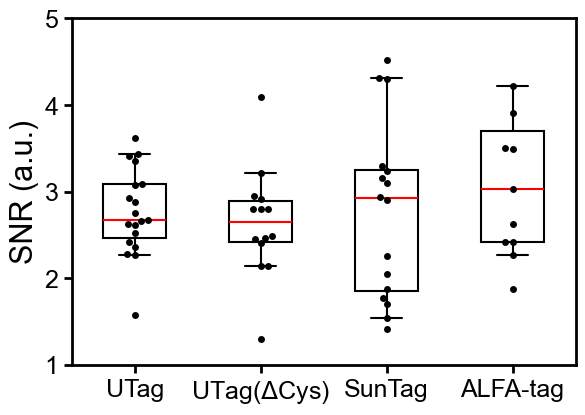

In [10]:
selected_field = 'snr_ch_0'  # psf_sigma_ch_0, psf_amplitude_ch_0, snr_ch_0, total_spot_int_ch_0, spot_int_ch_0
list_extracted_data, list_merged_data = extract_data(selected_field, list_datasets, selected_frame=selected_frame)
_,_, = plot_repetition_means_box_swarm_plot(
    list_extracted_data,
    list_constructs_names,
    x_label="",
    y_label="SNR (a.u.)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(1, 5),
    show_stats=show_stats,
    max_percentile_significance = 99.0,
    save_dir=results_folder,
    plot_name= "SNR",
    x_tick_rotation=0,
)


--- Mean Values for spot_size_um ---
  UTag: 0.325 ± 0.0047 (n=19)
  UTag($\Delta$Cys): 0.336 ± 0.0101 (n=14)
  SunTag: 0.363 ± 0.0118 (n=16)
  ALFA-tag: 0.324 ± 0.0059 (n=11)
--- End Mean Values ---


--- Statistical Comparisons for spot_size_um ---
  UTag vs UTag($\Delta$Cys): p = 0.927441 (ns)
  UTag vs SunTag: p = 0.002729 (**)
  UTag vs ALFA-tag: p = 0.575838 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.039615 (*)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.848050 (ns)
  SunTag vs ALFA-tag: p = 0.008290 (**)
--- End Statistical Comparisons ---



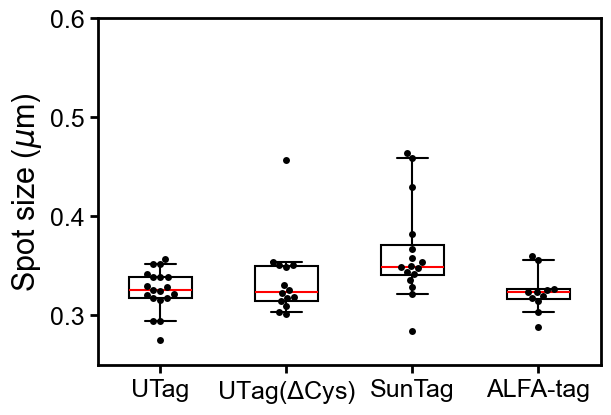

In [11]:
selected_field = 'spot_size_ch_0'  
list_extracted_data, list_merged_data = extract_data(selected_field, list_datasets, selected_frame=selected_frame)
list_extracted_data_um = [data * pixel_xy_um for data in list_extracted_data]
_,_, = plot_repetition_means_box_swarm_plot(
    list_extracted_data_um,
    list_constructs_names,
    x_label="",
    y_label=r"Spot size ($\mu$m)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(0.25, 0.6),
    show_stats=False,
    max_percentile_significance = 99.9,
    save_dir=results_folder,
    plot_name= "spot_size_um",
    x_tick_rotation=0,
)